#Deep Learning para visión de computadoras
##Lab 1.1 Introducción a visión por computadora


## Objetivos de aprendizaje

Al finalizar esta práctica, el estudiante será capaz de:

1. Configurar y verificar un entorno de trabajo en Google Colab con PyTorch, TorchVision y OpenCV.
2. Describir la representación digital de una imagen (píxeles, canales, resolución) y manipularla mediante operaciones básicas de lectura, color, geometría e intensidad.
3. Explorar el conjunto de datos CIFAR-10 con TorchVision: su estructura, sus clases y las características estadísticas de sus imágenes.

## Ejecución local
Desde la raíz del proyecto, ejecuta `uv sync` y selecciona `.venv/bin/python` como kernel del notebook. No se requiere una GPU.

<!-- Solo Google Colab: activar GPU en Entorno de ejecución → Cambiar tipo de entorno de ejecución → Acelerador de hardware → GPU (T4). -->


In [ ]:
# Solo Google Colab o equipos con GPU NVIDIA:
# !nvidia-smi


#Librerías

In [6]:
import importlib

# Las dependencias se administran con uv desde la raíz del proyecto: uv sync
paquetes = ["torch", "torchvision", "cv2", "matplotlib", "numpy", "PIL", "skimage"]

for paquete in paquetes:
    mod = importlib.import_module(paquete)
    version = getattr(mod, "__version__", "instalado (sin atributo __version__)")
    print(f"[OK] {paquete}: {version}")


[OK] torch: 2.14.0
[OK] torchvision: 0.29.0
[OK] cv2: 5.0.0
[OK] matplotlib: 3.11.1
[OK] numpy: 2.5.3
[OK] PIL: 12.3.0
[OK] skimage: 0.26.0


In [7]:
import torch
import torchvision
import cv2

print("PyTorch     :", torch.__version__)
print("TorchVision :", torchvision.__version__)
print("OpenCV      :", cv2.__version__)
print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch     : 2.14.0
TorchVision : 0.29.0
OpenCV      : 5.0.0
CUDA disponible: False


`cv2_imshow` se define localmente con Matplotlib para mostrar imágenes de OpenCV en formato BGR, BGRA o escala de grises. El import original de Google Colab queda comentado.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
# Solo Google Colab:
# from google.colab.patches import cv2_imshow


def cv2_imshow(img):
    """Muestra una imagen de OpenCV dentro del notebook local."""
    plt.figure()
    if img.ndim == 2:
        plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    elif img.shape[2] == 1:
        plt.imshow(img[:, :, 0], cmap="gray", vmin=0, vmax=255)
    else:
        conversion = cv2.COLOR_BGRA2RGBA if img.shape[2] == 4 else cv2.COLOR_BGR2RGB
        plt.imshow(cv2.cvtColor(img, conversion))
    plt.axis("off")
    plt.show()


plt.rcParams["figure.figsize"] = (6, 6)
print("Listo")


Listo


## Parte A. Manipulación de imágenes

In [9]:
# Instalación en Google Colab:
# !pip install -q scikit-image
# Localmente: scikit-image está incluido en las dependencias de uv.


Tipo de dato   : <class 'numpy.ndarray'>
Forma (shape)  : (400, 600, 3)
Tipo de pixel  : uint8
Valor mínimo   : 0
Valor máximo   : 255


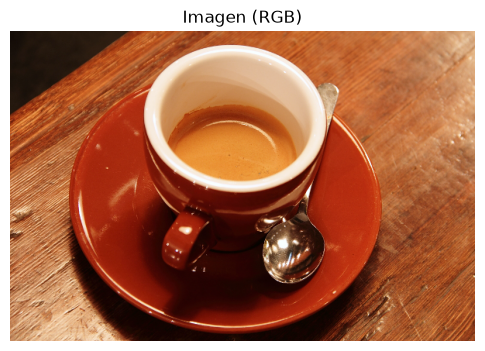

In [10]:
from skimage import data

# Imagen ej en RGB, formato numpy (alto, ancho, canales)
imagen_rgb = data.coffee()

print("Tipo de dato   :", type(imagen_rgb))
print("Forma (shape)  :", imagen_rgb.shape)
print("Tipo de pixel  :", imagen_rgb.dtype)
print("Valor mínimo   :", imagen_rgb.min())
print("Valor máximo   :", imagen_rgb.max())

plt.imshow(imagen_rgb)
plt.title("Imagen (RGB)")
plt.axis("off")
plt.show()


**OpenCV vs. Matplotlib: el orden de canales BGR/RGB**

Formato OpenCV: (400, 600, 3)
Formato cv2_imshow (interpreta BGR correctamente):


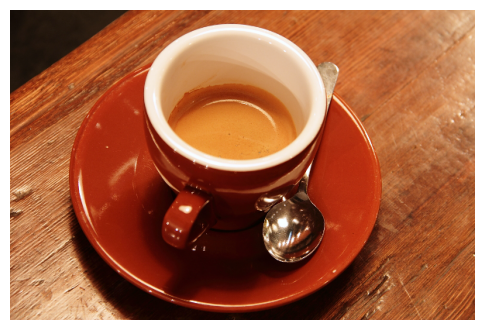

In [11]:
import cv2
# a) Guarda imagen directamente
#cv2.imwrite("cafe.png", (imagen_rgb))

# b) Guardamos la imagen de skimage (RGB) a disco y la volvemos a leer con OpenCV
cv2.imwrite("cafe.png", cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2BGR))

imagen_bgr = cv2.imread("cafe.png")   # OpenCV siempre lee en BGR
print("Formato OpenCV:", imagen_bgr.shape)

# cv2_imshow interpreta el arreglo como BGR
print("Formato cv2_imshow (interpreta BGR correctamente):")
cv2_imshow(imagen_bgr)


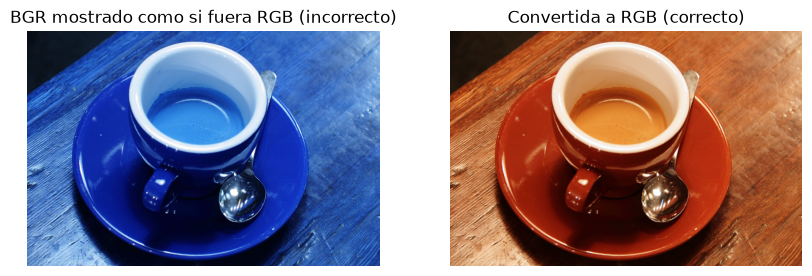

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(imagen_bgr)
ax[0].set_title("BGR mostrado como si fuera RGB (incorrecto)")
ax[0].axis("off")
#print("Formato OpenCV:", imagen_bgr.shape)

imagen_bgr_a_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
ax[1].imshow(imagen_bgr_a_rgb)
ax[1].set_title("Convertida a RGB (correcto)")
ax[1].axis("off")
plt.show()
#print("Formato OpenCV:", imagen_bgr_a_rgb.shape)


**Canales**

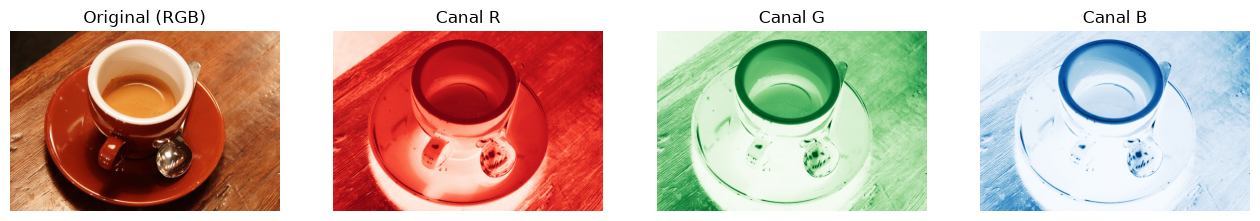

In [13]:
R = imagen_rgb[:, :, 0]
G = imagen_rgb[:, :, 1]
B = imagen_rgb[:, :, 2]

fig, ax = plt.subplots(1, 4, figsize=(16, 5))
ax[0].imshow(imagen_rgb); ax[0].set_title("Original (RGB)"); ax[0].axis("off")
ax[1].imshow(R, cmap="Reds");   ax[1].set_title("Canal R"); ax[1].axis("off")
ax[2].imshow(G, cmap="Greens"); ax[2].set_title("Canal G"); ax[2].axis("off")
ax[3].imshow(B, cmap="Blues");  ax[3].set_title("Canal B"); ax[3].axis("off")
plt.show()

#print("Forma de cada canal:", R.shape)

**Escala de grises**

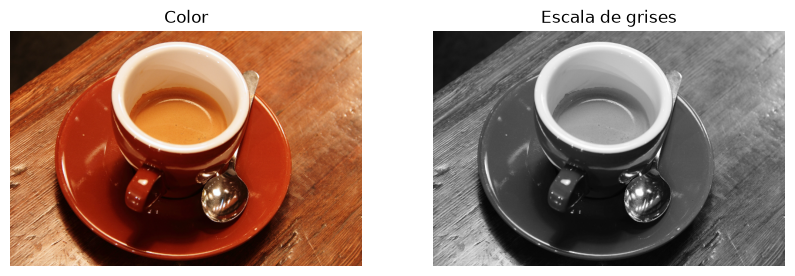

In [14]:
imagen_gris = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(imagen_rgb); ax[0].set_title("Color"); ax[0].axis("off")
ax[1].imshow(imagen_gris, cmap="gray"); ax[1].set_title("Escala de grises"); ax[1].axis("off")
plt.show()

**Transformaciones geométricas**

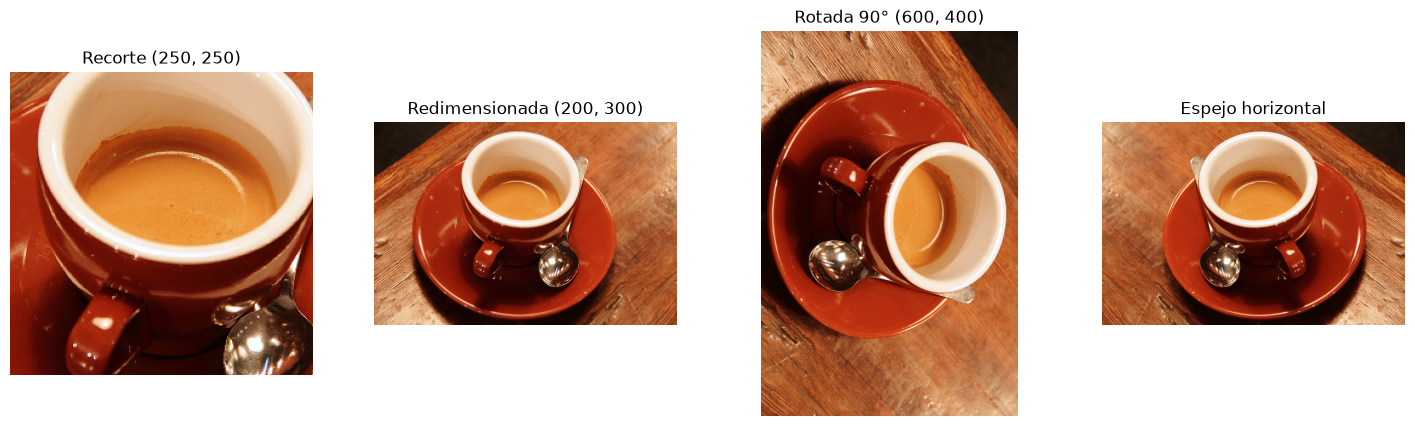

In [15]:
alto, ancho = imagen_rgb.shape[:2]

# Recorte: seleccionar una región de interés (ROI)
recorte = imagen_rgb[50:300, 150:400]

# Redimensionamiento
redimensionada = cv2.resize(imagen_rgb, (ancho // 2, alto // 2))

# Rotación 90 grados
rotada = cv2.rotate(imagen_rgb, cv2.ROTATE_90_CLOCKWISE)

# Espejo horizontal (flip)
espejo = cv2.flip(imagen_rgb, 1)

fig, ax = plt.subplots(1, 4, figsize=(18, 5))
ax[0].imshow(recorte); ax[0].set_title(f"Recorte {recorte.shape[:2]}"); ax[0].axis("off")
ax[1].imshow(redimensionada); ax[1].set_title(f"Redimensionada {redimensionada.shape[:2]}"); ax[1].axis("off")
ax[2].imshow(rotada); ax[2].set_title(f"Rotada 90° {rotada.shape[:2]}"); ax[2].axis("off")
ax[3].imshow(espejo); ax[3].set_title("Espejo horizontal"); ax[3].axis("off")
plt.show()


**Brillo y contraste**
Simple operación aritmética **punto a punto** (no espacial):

$$ I_{salida}(x,y) = \alpha \cdot I_{entrada}(x,y) + \beta $$

donde $\alpha$ controla el contraste y $\beta$ controla el brillo

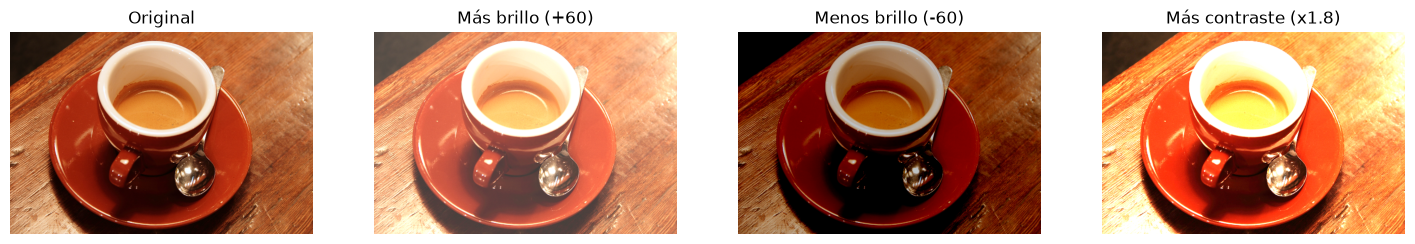

In [16]:
def ajustar_brillo_contraste(img, alpha=1.0, beta=0):
    """alpha: contraste (1.0 = sin cambio) | beta: brillo (0 = sin cambio)"""
    ajustada = img.astype(np.float32) * alpha + beta
    ajustada = np.clip(ajustada, 0, 255).astype(np.uint8)
    return ajustada

mas_brillo   = ajustar_brillo_contraste(imagen_rgb, alpha=1.0, beta=60)
menos_brillo = ajustar_brillo_contraste(imagen_rgb, alpha=1.0, beta=-60)
mas_contraste = ajustar_brillo_contraste(imagen_rgb, alpha=1.8, beta=0)

fig, ax = plt.subplots(1, 4, figsize=(18, 5))
ax[0].imshow(imagen_rgb); ax[0].set_title("Original"); ax[0].axis("off")
ax[1].imshow(mas_brillo); ax[1].set_title("Más brillo (+60)"); ax[1].axis("off")
ax[2].imshow(menos_brillo); ax[2].set_title("Menos brillo (-60)"); ax[2].axis("off")
ax[3].imshow(mas_contraste); ax[3].set_title("Más contraste (x1.8)"); ax[3].axis("off")
plt.show()


**Histograma**
Muestra la distribución de valores de intensidad de una imagen; es una herramienta descriptiva.

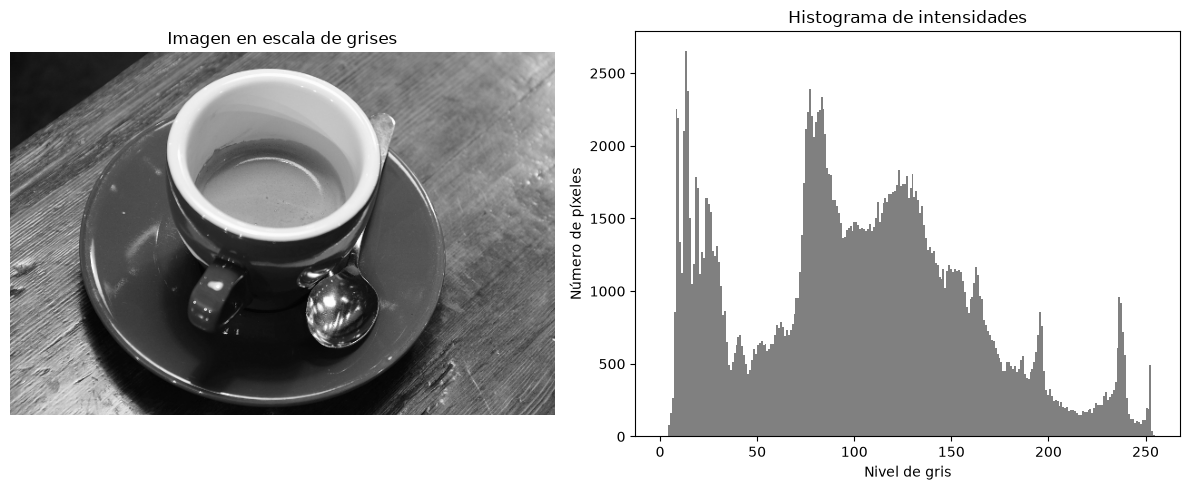

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(imagen_gris, cmap="gray")
ax[0].set_title("Imagen en escala de grises")
ax[0].axis("off")

ax[1].hist(imagen_gris.ravel(), bins=256, range=(0, 255), color="gray")
ax[1].set_title("Histograma de intensidades")
ax[1].set_xlabel("Nivel de gris")
ax[1].set_ylabel("Número de píxeles")
plt.tight_layout()
plt.show()

## Parte B. Datos CIFAR-10

Trabajaremos con el conjunto de datos CIFAR 10, podemos encontrar este conjunto de datos dentro de la API de keras, por lo que una forma de obtenerlo es:

from tensorflow import keras as K
(x_train, y_train),(x_test, y_test) = K.datasets.cifar10.load_data()

El conjunto de datos CIFAR-10 consta de 60000 imágenes de 32x32 colores (32, 32, 3) en 10 clases, con 6000 imágenes por clase. Hay 50000 imágenes de entrenamiento y 10000 imágenes de prueba.

El conjunto de datos se divide en cinco lotes de entrenamiento y un lote de prueba, cada uno con 10000 imágenes. El lote de prueba contiene exactamente 1000 imágenes seleccionadas al azar de cada clase. Los lotes de entrenamiento contienen las imágenes restantes en orden aleatorio, pero algunos lotes de entrenamiento pueden contener más imágenes de una clase que de otra. Entre ellos, los lotes de capacitación contienen exactamente 5000 imágenes de cada clase.

Las clases son completamente excluyentes entre sí. No hay superposición entre automóviles y camiones. “Automóvil” incluye sedanes, SUV, cosas por el estilo. “Camión” incluye solo camiones grandes. Tampoco incluye camionetas.
En conclusión, obtendremos 60000 imágenes y 60000 etiquetas.

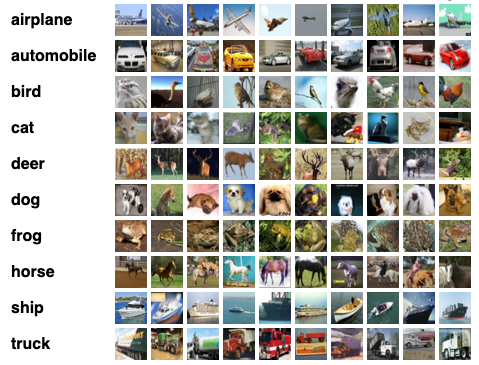

Documentación adicional : Explorar en artículos con código north_east

Página de inicio : https://www.cs.toronto.edu/~kriz/cifar.html

Código fuente : tfds.image_classification.Cifar10

Versiones :

3.0.2 (predeterminado): Sin notas de la versión.
Tamaño de descarga : 162.17 MiB

Tamaño del conjunto de datos : 132.40 MiB

Almacenamiento en caché automático ( documentación ): Sí

Divisiones :

Dividir	Ejemplos
'test'	10.000
'train'	50.000
Estructura de características :

FeaturesDict({
    'id': Text(shape=(), dtype=string),
    'image': Image(shape=(32, 32, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
})

https://www.kaggle.com/datasets/ghnshymsaini/cifar-10-image-dataset


In [18]:
from pathlib import Path

# Compartir CIFAR-10 entre actividades, desde la raíz o la carpeta del notebook.
_course_name = "Deep-Learning-Vision-Computer-Class"
_course_root = next(
    (candidate for parent in (Path.cwd(), *Path.cwd().parents)
     for candidate in (parent, parent / _course_name, parent / "semester-v" / _course_name)
     if candidate.name == _course_name and (candidate / "u1").is_dir()),
    None,
)
if _course_root is None:
    raise FileNotFoundError("Ejecuta el notebook desde el repositorio o una carpeta del curso.")
CIFAR_DATA_DIR = _course_root / "data" / "cifar-10"
CIFAR_DATA_DIR.mkdir(parents=True, exist_ok=True)

import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Definir transformación básica para convertir la imagen a Tensor PyTorch (C, H, W) valores [0 1]
transform = transforms.Compose([
    transforms.ToTensor()
])

print("Descargando dataset CIFAR-10...")
trainset = torchvision.datasets.CIFAR10(
    root=str(CIFAR_DATA_DIR),
    train=True,
    download=True,
    transform=transform
)

classes = ('Avión', 'Automóvil', 'Pájaro', 'Gato', 'Ciervo',
           'Perro', 'Rana', 'Caballo', 'Barco', 'Camión')



Descargando dataset CIFAR-10...


100.0%


**Ejercicio: Estructura del dataset**

In [19]:
image, label = trainset[0]

print("Tipo de dato        : ", type(image))
print("Forma del tensor    : ", image.shape)
print("Rango de valores    : ", image.min().item(), image.max().item())
print("Etiqueta (índice)   : ", label)
print("Etiqueta (clase)    : ", classes[label])

Tipo de dato        :  <class 'torch.Tensor'>
Forma del tensor    :  torch.Size([3, 32, 32])
Rango de valores    :  0.0 1.0
Etiqueta (índice)   :  6
Etiqueta (clase)    :  Rana


**Extraer exactamente 1 imagen representativa por cada clase**

In [20]:
images_per_class = {}
for image, label in trainset:
    if label not in images_per_class:
        images_per_class[label] = image
    if len(images_per_class) == 10:
        break


**Visualizar las 10 imágenes en una cuadrícula de 2x5**

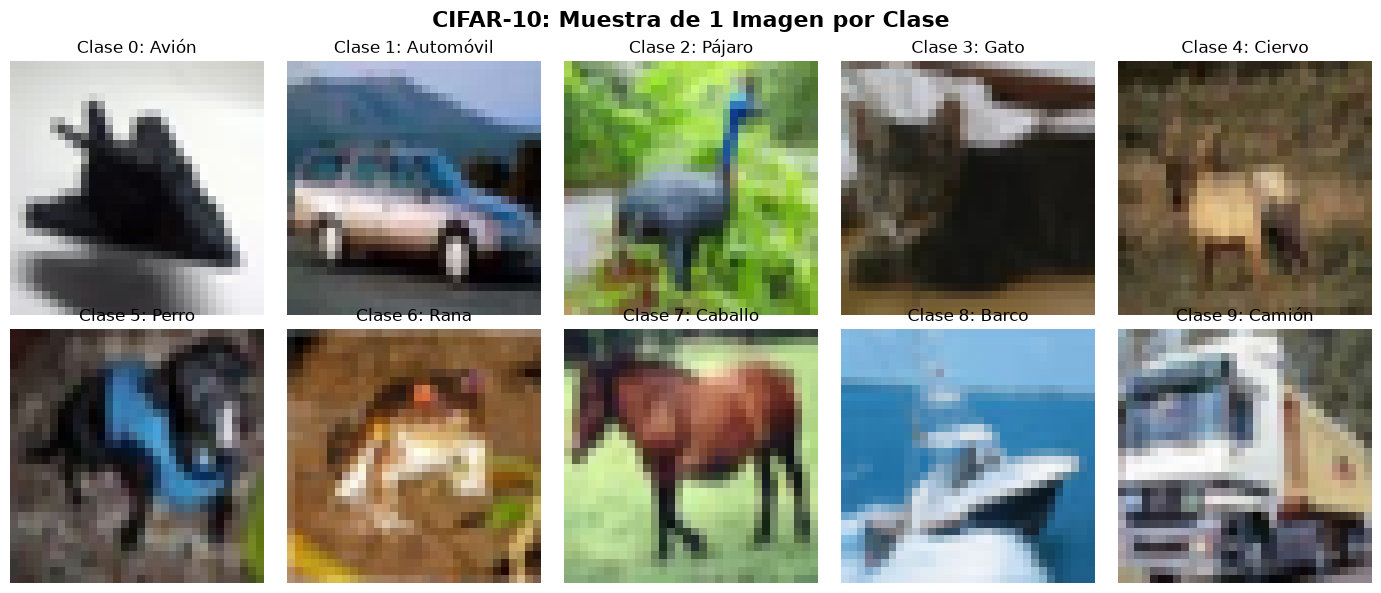

Dimensiones de cada imagen: torch.Size([3, 32, 32]) (Canales x Alto x Ancho)


In [21]:

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("CIFAR-10: Muestra de 1 Imagen por Clase", fontsize=16, fontweight='bold')

for label_idx in range(10):
    row = label_idx // 5
    col = label_idx % 5

    # En PyTorch el formato es (Canales, Altura, Ancho) -> Transponemos a (Altura, Ancho, Canales) para Matplotlib
    img_tensor = images_per_class[label_idx]
    img_np = img_tensor.permute(1, 2, 0).numpy()

    axes[row, col].imshow(img_np)
    axes[row, col].set_title(f"Clase {label_idx}: {classes[label_idx]}")
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print(f"Dimensiones de cada imagen: {img_tensor.shape} (Canales x Alto x Ancho)")

**Ejercicio: Separación de canales, conversión a escala de grises e histograma de 4 imagenes**

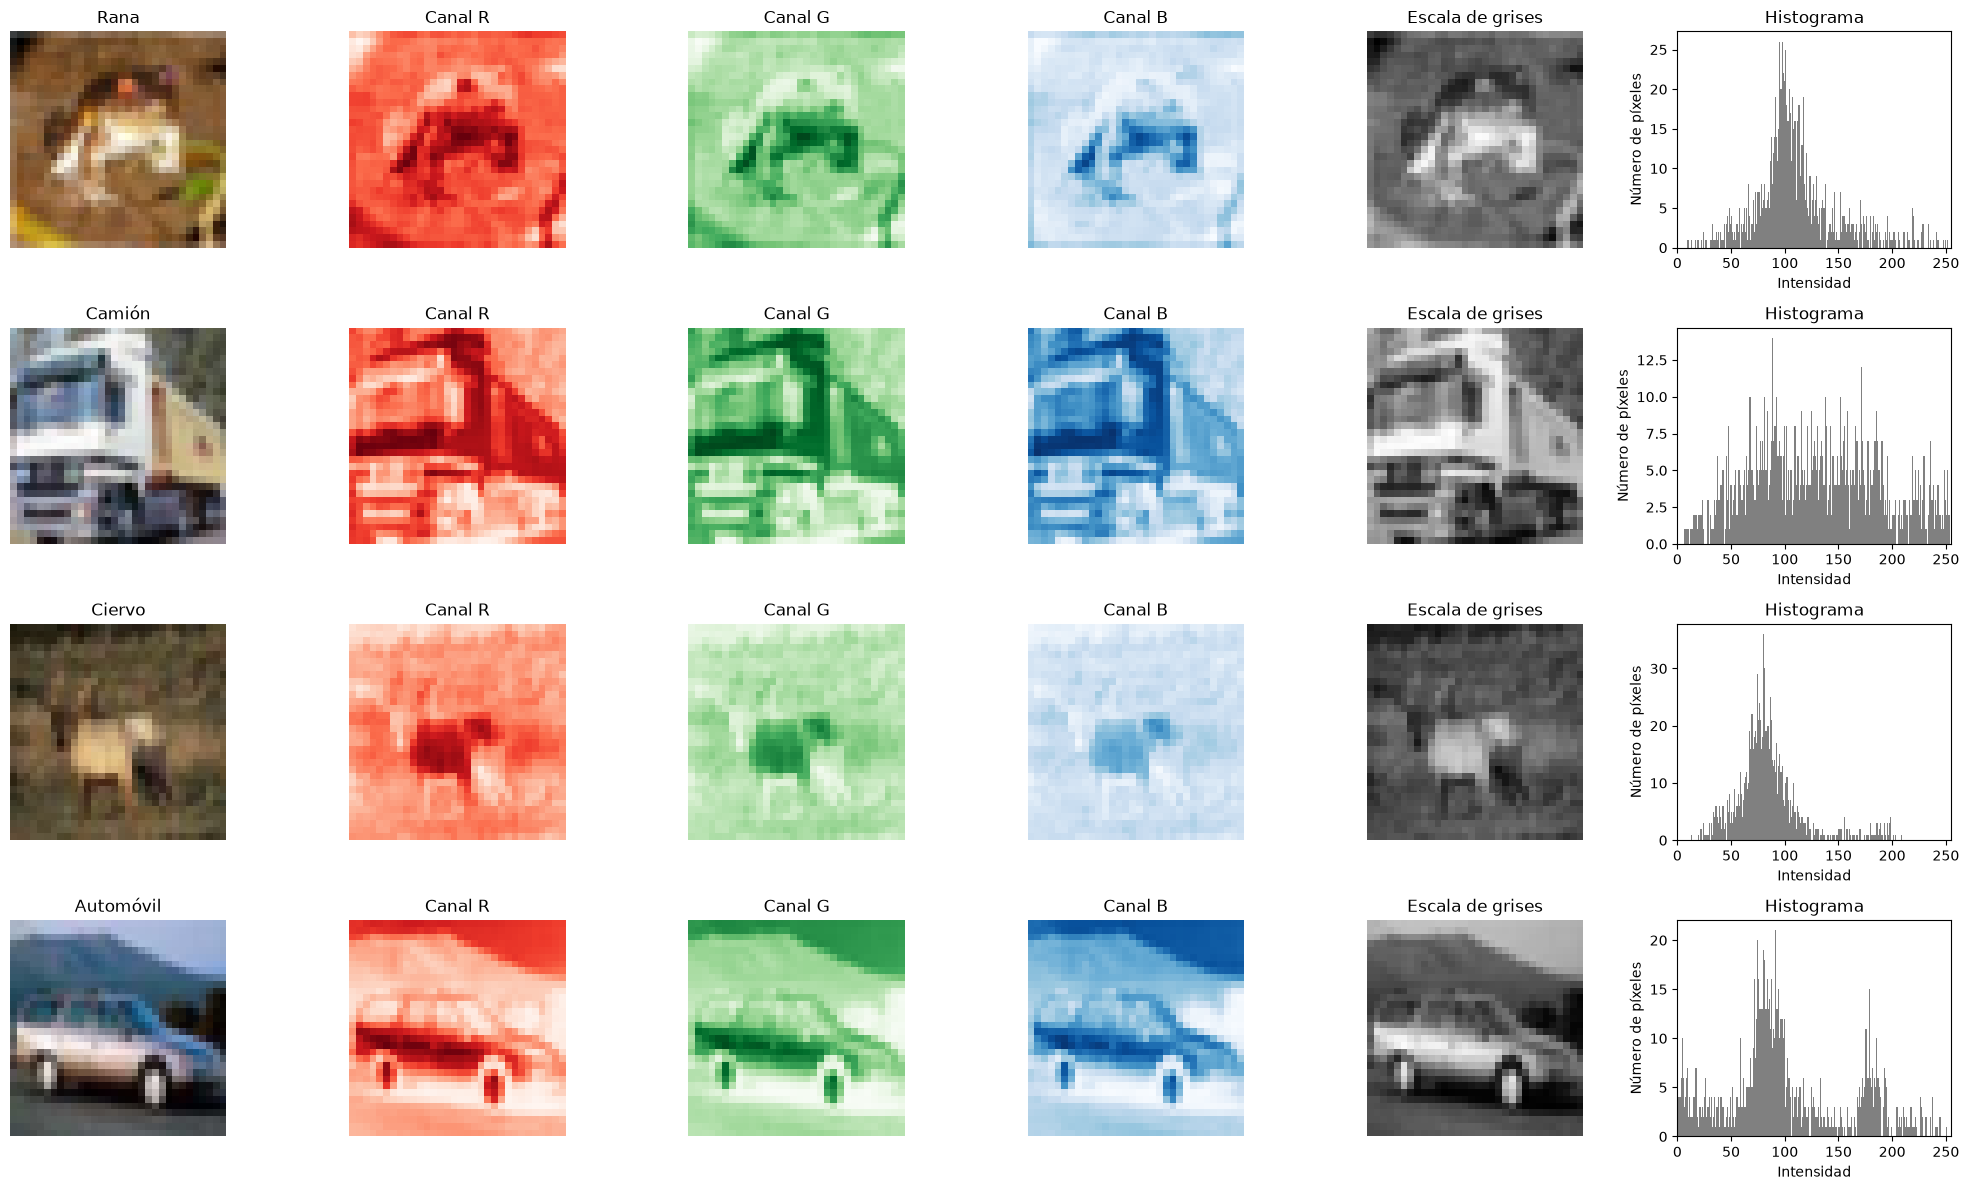

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Seleccionar 4 imagenes de diferentes clases
selected_images = {}
for image, label in trainset:
    if label not in selected_images:
        selected_images[label] = image
    if len(selected_images) == 4:
        break

fig, axes = plt.subplots(4, 6, figsize=(20, 12))

for row, (label, image) in enumerate(selected_images.items()):
    # Conversion (C, H, W), float [0, 1] → (H, W, C), uint8 [0, 255].
    imagen_rgb = (
        image.permute(1, 2, 0).numpy() * 255
    ).round().astype(np.uint8)

    R = imagen_rgb[:, :, 0]
    G = imagen_rgb[:, :, 1]
    B = imagen_rgb[:, :, 2]

    imagen_gris = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)

    axes[row, 0].imshow(imagen_rgb)
    axes[row, 0].set_title(classes[label])

    for col, channel, cmap, title in [
        (1, R, "Reds", "Canal R"),
        (2, G, "Greens", "Canal G"),
        (3, B, "Blues", "Canal B"),
    ]:
        axes[row, col].imshow(channel, cmap=cmap, vmin=0, vmax=255)
        axes[row, col].set_title(title)

    axes[row, 4].imshow(imagen_gris, cmap="gray", vmin=0, vmax=255)
    axes[row, 4].set_title("Escala de grises")

    axes[row, 5].hist(
        imagen_gris.ravel(),
        bins=256,
        range=(0, 256),
        color="gray",
    )
    axes[row, 5].set_title("Histograma")
    axes[row, 5].set_xlabel("Intensidad")
    axes[row, 5].set_ylabel("Número de píxeles")
    axes[row, 5].set_xlim(0, 255)

    for col in range(5):
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

**Ejercicio: Elige una imagen de CIFAR-10 y aplica tres combinaciones distintas de $\alpha$ y $\beta$ (ver sección 1.6). Muestra los resultados en una sola figura y comenta qué combinación conserva mejor los detalles.**

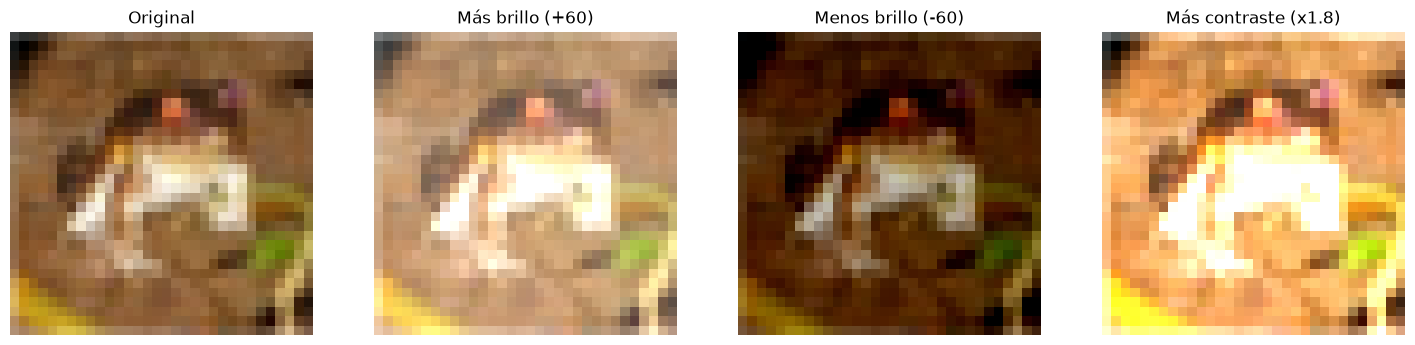

In [25]:
image, label = trainset[0]

imagen_rgb = (
    image.permute(1, 2, 0).numpy() * 255
).round().astype(np.uint8)

def ajustar_brillo_contraste(img, alpha=1.0, beta=0):
  """alpha: contraste (1.0 = sin cambio) | beta: brillo (0 = sin cambio)"""
  ajustada = img.astype(np.float32) * alpha + beta
  ajustada = np.clip(ajustada, 0, 255).astype(np.uint8)
  return ajustada

mas_brillo   = ajustar_brillo_contraste(imagen_rgb, alpha=1.0, beta=60)
menos_brillo = ajustar_brillo_contraste(imagen_rgb, alpha=1.0, beta=-60)
mas_contraste = ajustar_brillo_contraste(imagen_rgb, alpha=1.8, beta=0)

fig, ax = plt.subplots(1, 4, figsize=(18, 5))
ax[0].imshow(imagen_rgb); ax[0].set_title("Original"); ax[0].axis("off")
ax[1].imshow(mas_brillo); ax[1].set_title("Más brillo (+60)"); ax[1].axis("off")
ax[2].imshow(menos_brillo); ax[2].set_title("Menos brillo (-60)"); ax[2].axis("off")
ax[3].imshow(mas_contraste); ax[3].set_title("Más contraste (x1.8)"); ax[3].axis("off")
plt.show()